In [1]:
pip install gymnasium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 47.0 MB/s eta 0:00:00


In [8]:
import numpy as np
from collections import defaultdict
import gymnasium as gym
import matplotlib.pyplot as plt
import pickle

# Define the default Q-value function
def default_q_value():
    return np.zeros(2)  # Two actions: 0 (Stand), 1 (Hit)

# Blackjack Environment
class BlackjackEnv(gym.Env):
    def __init__(self, render_mode=None, natural=False, sab=False, total_decks=5, include_count=False):
        super(BlackjackEnv, self).__init__()
        self.include_count = include_count
        self.action_space = gym.spaces.Discrete(2)  # 0: Stand, 1: Hit

        if self.include_count:
            self.observation_space = gym.spaces.Tuple(
                (
                    gym.spaces.Discrete(32),   # Player's current sum (0-31)
                    gym.spaces.Discrete(11),   # Dealer's visible card (1-10)
                    gym.spaces.Discrete(2),    # Usable Ace (0: No, 1: Yes)
                    gym.spaces.Discrete(101),  # Player's money (0-100)
                    gym.spaces.Discrete(41),   # Running Count shifted from [-20,20] to [0,40]
                    gym.spaces.Discrete(21)     # Remaining Decks (0-20)
                )
            )
        else:
            self.observation_space = gym.spaces.Tuple(
                (
                    gym.spaces.Discrete(32),   # Player's current sum (0-31)
                    gym.spaces.Discrete(11),   # Dealer's visible card (1-10)
                    gym.spaces.Discrete(2),    # Usable Ace (0: No, 1: Yes)
                    gym.spaces.Discrete(101)   # Player's money (0-100)
                )
            )

        self.natural = natural
        self.sab = sab
        self.render_mode = render_mode
        self.running_count = 0
        self.betting_unit = 1
        self.money = 50
        self.current_bet = 1
        one_suite = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        self.original_deck = one_suite * 4 * total_decks
        self.deck = self.original_deck.copy()

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid Action: {action}"
        if action == 1:
            self.player.append(self.draw_card())
            if self.is_bust(self.player):
                terminated = True
                reward = -1.0
            else:
                terminated = False
                reward = 0.0
        else:
            terminated = True
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card())
            reward = self.cmp(self.score(self.player), self.score(self.dealer))
            if self.sab and self.is_natural(self.player) and not self.is_natural(self.dealer):
                reward = 1.0
            elif not self.sab and self.natural and self.is_natural(self.player) and reward == 1.0:
                reward = 1.5

        # Update money and ensure it doesn't go below 0
        self.money = max(self.money + reward * self.current_bet, 0)
        return self._get_state(), reward, terminated
    def _get_obs(self):
        if self.include_count:
            shifted_count = self.running_count + 20
            shifted_count = np.clip(shifted_count, 0, 40)
            remaining_decks = self.getRemainingDecks()
            return (
                self.sum_hand(self.player),
                self.dealer[0],
                int(self.usable_ace(self.player)),
                self.money,
                shifted_count,
                remaining_decks
            )
        else:
            return (
                self.sum_hand(self.player),
                self.dealer[0],
                int(self.usable_ace(self.player)),
                self.money
            )

    def _get_state(self):
        return self.sum_hand(self.player), self.dealer[0], int(self.usable_ace(self.player)), self.running_count, self.getRemainingDecks()

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.money = 50
        self.deck = self.original_deck.copy()
        self.running_count = 0
        return self.new_round()

    def new_round(self):
        self.dealer = self.draw_hand()
        self.player = self.draw_hand()
        return self._get_state()

    def draw_card(self):
        if len(self.deck) == 0:
            raise ValueError("The deck is empty!")
        card = self.deck.pop(np.random.randint(len(self.deck)))
        if self.include_count:
            if card in [1, 10]:
                self.running_count -= 1
            elif 2 <= card <= 6:
                self.running_count += 1
        return card

    def draw_hand(self):
        return [self.draw_card(), self.draw_card()]

    def getRemainingDecks(self):
        return min(round(len(self.deck) / 52 * 2) / 2, 20)

    @staticmethod
    def cmp(a, b):
        return float(a > b) - float(a < b)

    @staticmethod
    def usable_ace(hand):
        return 1 in hand and sum(hand) + 10 <= 21

    @staticmethod
    def sum_hand(hand):
        if BlackjackEnv.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)

    @staticmethod
    def is_bust(hand):
        return BlackjackEnv.sum_hand(hand) > 21

    @staticmethod
    def score(hand):
        return 0 if BlackjackEnv.is_bust(hand) else BlackjackEnv.sum_hand(hand)

    @staticmethod
    def is_natural(hand):
        return sorted(hand) == [1, 10]

In [37]:
import numpy as np
from collections import deque
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# DQN Agent Class
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.99  # Discount factor
        self.epsilon = 1.0  # Exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.1
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self._build_model().to(self.device)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=self.learning_rate)

    def _build_model(self):
        """Build a neural network model."""
        return nn.Sequential(
            nn.Linear(self.state_size, 24),
            nn.ReLU(),
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, self.action_size)  # Output raw Q-values
        )

    def remember(self, state, action, reward, next_state, done):
        """Store experience in memory."""
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        """Choose an action using epsilon-greedy policy."""
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            act_values = self.model(state)
        return act_values.argmax().item()

    def replay(self, batch_size):
        """Train the model on a batch of experiences."""
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        # Convert to tensors and remove the extra dimension
        states = torch.FloatTensor(states).to(self.device).squeeze(1)  # Remove the extra dimension
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)  # Reshape actions to (batch_size, 1)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device).squeeze(1)  # Remove the extra dimension
        dones = torch.FloatTensor(dones).to(self.device)

        # Debugging output to track dimensions
        # print(f"states.shape: {states.shape}")
        # print(f"actions.shape: {actions.shape}")
        # print(f"rewards.shape: {rewards.shape}")
        # print(f"next_states.shape: {next_states.shape}")
        # print(f"dones.shape: {dones.shape}")

        current_q_values = self.model(states).gather(1, actions)
        # print(f"current_q_values.shape: {current_q_values.shape}")

        next_q_values = self.model(next_states).max(1)[0]
        # print(f"next_q_values.shape: {next_q_values.shape}")

        target_q_values = rewards + (1 - dones) * self.gamma * next_q_values
        # print(f"target_q_values.shape: {target_q_values.shape}")

        loss = nn.MSELoss()(current_q_values, target_q_values.unsqueeze(1))
        # print(f"loss: {loss.item()}")

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# Train the DQN Agent
def train_dqn(env, agent, episodes, batch_size):
    money_per_episode_DQN = []
    for episode in range(1, episodes+1):
        # print(f"Episode: {episode}")
        state = env.reset()
        done = False
        money_history = [env.money]
        total_reward = 0
        # while env.money > 0 and env.getRemainingDecks() > 0.5:
        #     state = np.reshape(state, [1, agent.state_size])
        while not done:
            if env.money == 0 or env.getRemainingDecks() < 1:
                env.reset()
            state = np.reshape(state, [1, agent.state_size])
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            next_state = np.reshape(next_state, [1, agent.state_size])
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            money_history.append(env.money)

        if len(agent.memory) > batch_size:
            agent.replay(batch_size)

        money_per_episode_DQN.append(money_history)
    return money_per_episode_DQN

# Evaluate the trained DQN Agent
def evaluate_dqn(env, agent, episodes):
    money_per_episode_DQN = []
    for episode in range(1, episodes+1):
        state = env.reset()
        done = False
        money_history = [env.money]
        total_reward = 0
        # while env.money > 0 and env.getRemainingDecks() > 0.5:
            # state = np.reshape(state, [1, agent.state_size])
        while not done:
            if env.money == 0 or env.getRemainingDecks() < 1:
              env.reset()
            state = np.reshape(state, [1, agent.state_size])
            state_tensor = torch.FloatTensor(state).to(agent.device)
            with torch.no_grad():
                action = agent.model(state_tensor).argmax().item()
            next_state, reward, done = env.step(action)
            next_state = np.reshape(next_state, [1, agent.state_size])
            state = next_state
            total_reward += reward
            money_history.append(env.money)
        money_per_episode_DQN.append(money_history)
    return money_per_episode_DQN

# Initialize Environment and Agent
env = BlackjackEnv(include_count=False)
state_size = 5
action_size = env.action_space.n
agent = DQNAgent(state_size, action_size)

# Train the agent
training_episodes = 100
batch_size = 32
training_scores = train_dqn(env, agent, training_episodes, batch_size)

# Evaluate the agent
evaluation_episodes = 50
evaluation_scores = evaluate_dqn(env, agent, evaluation_episodes)

# Extract total rewards for each episode
# training_rewards = [sum(money) for money in training_scores]
# evaluation_rewards = [sum(money) for money in evaluation_scores]

training_scores =  [item for sublist in training_scores for item in sublist]
evaluation_scores = [item for sublist in evaluation_scores for item in sublist]



Training Scores:  [50, 49.0, 50, 50.0, 51.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 50.0, 49.0, 50, 51.0, 50, 49.0, 50, 51.0, 50, 51.0, 50, 49.0, 50, 49.0, 50, 50.0, 49.0, 50, 49.0, 50, 49.0, 50, 50.0, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 50.0, 50.0, 49.0, 50, 49.0, 50, 50.0, 51.0, 50, 51.0, 50, 49.0, 50, 50.0, 51.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 50.0, 51.0, 50, 50.0, 49.0, 50, 50.0, 51.0, 50, 49.0, 50, 50.0, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 51.0, 50, 49.0, 50, 49.0, 50, 51.0, 50, 49.0, 50, 50.0, 51.0, 50, 49.0, 50, 49.0, 50, 50.0, 50, 50.0, 49.0, 50, 51.0, 50, 50.0, 50.0, 49.0, 50, 50.0, 49.0, 50, 49.0, 50, 51.0, 50, 49.0, 50, 50.0, 49.0, 50, 49.0, 50, 49.0, 50, 49.0, 50, 50.0, 51.0, 50, 49.0, 50, 50.0, 50.0, 49.0, 50, 49.0, 50, 51.0, 50, 50.0, 49.0, 50, 50.0, 50.0, 51.0, 50, 51.0, 50, 49.0, 50, 50.0, 49.0, 50, 50.0, 51.0, 50, 49.0, 50, 50.0, 49.0, 50, 49.0, 50, 51.0, 50, 49.0,

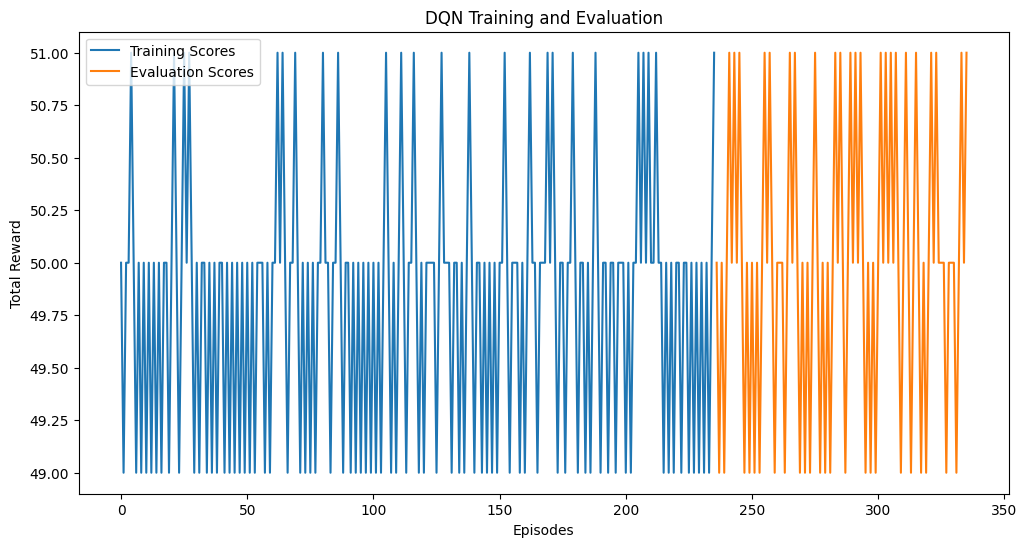

In [40]:
print("Training Scores: ", training_scores)
print("Evaluation Scores: ", evaluation_scores)

# Plot results
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(range(len(training_scores)), training_scores, label='Training Scores')
plt.plot(range(len(training_scores), len(training_scores) + len(evaluation_scores)),
         evaluation_scores, label='Evaluation Scores')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('DQN Training and Evaluation')
plt.legend()
plt.show()